
Processing BETH-USD
Metrics for BETH-USD: RMSE=147.1148, MAE=103.0251, MAPE=4.67%, R2=0.8115
Saved historical forecast CSV: ../../results/XGBoost_csv/separate_coins/BETH-USD_historical_forecast.csv
Saved test forecast CSV: ../../results/XGBoost_csv/separate_coins/BETH-USD_test_forecast.csv
Saved future forecast CSV: ../../results/XGBoost_csv/separate_coins/BETH-USD_future_forecast.csv
Saved model to: ../../saved_models/xgb_model_BETH-USD.pkl


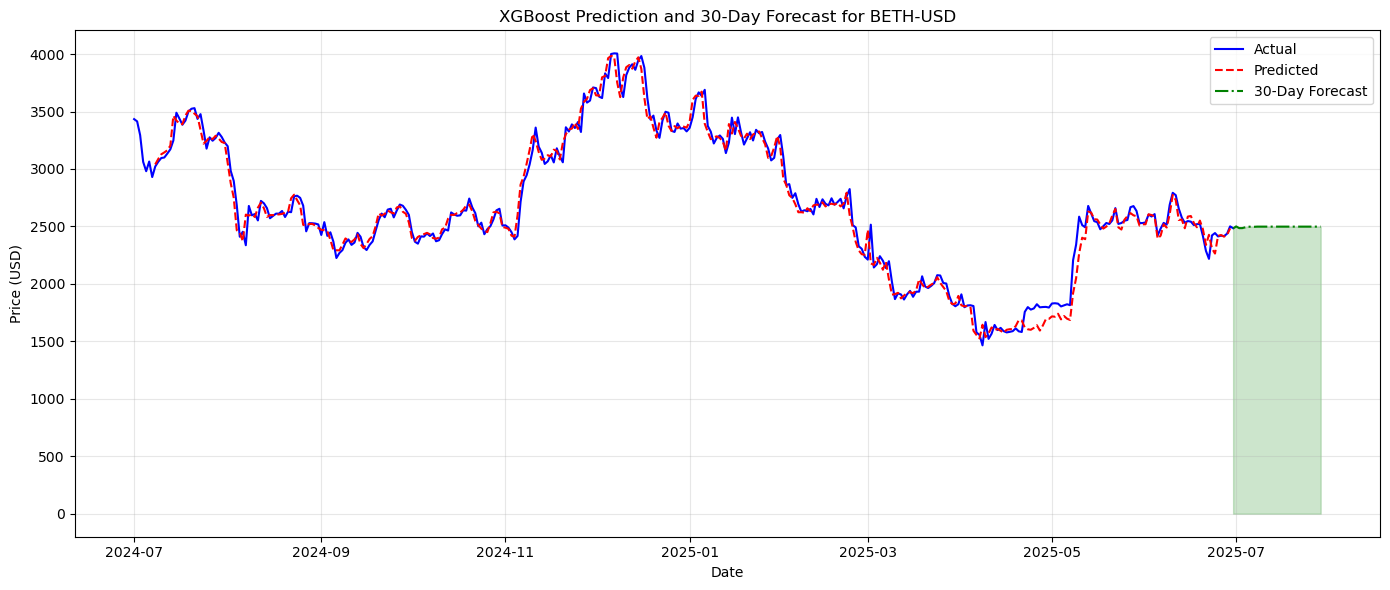


Processing BTC-USD
Metrics for BTC-USD: RMSE=3930.5613, MAE=3128.8816, MAPE=2.97%, R2=0.5217
Saved historical forecast CSV: ../../results/XGBoost_csv/separate_coins/BTC-USD_historical_forecast.csv
Saved test forecast CSV: ../../results/XGBoost_csv/separate_coins/BTC-USD_test_forecast.csv
Saved future forecast CSV: ../../results/XGBoost_csv/separate_coins/BTC-USD_future_forecast.csv
Saved model to: ../../saved_models/xgb_model_BTC-USD.pkl


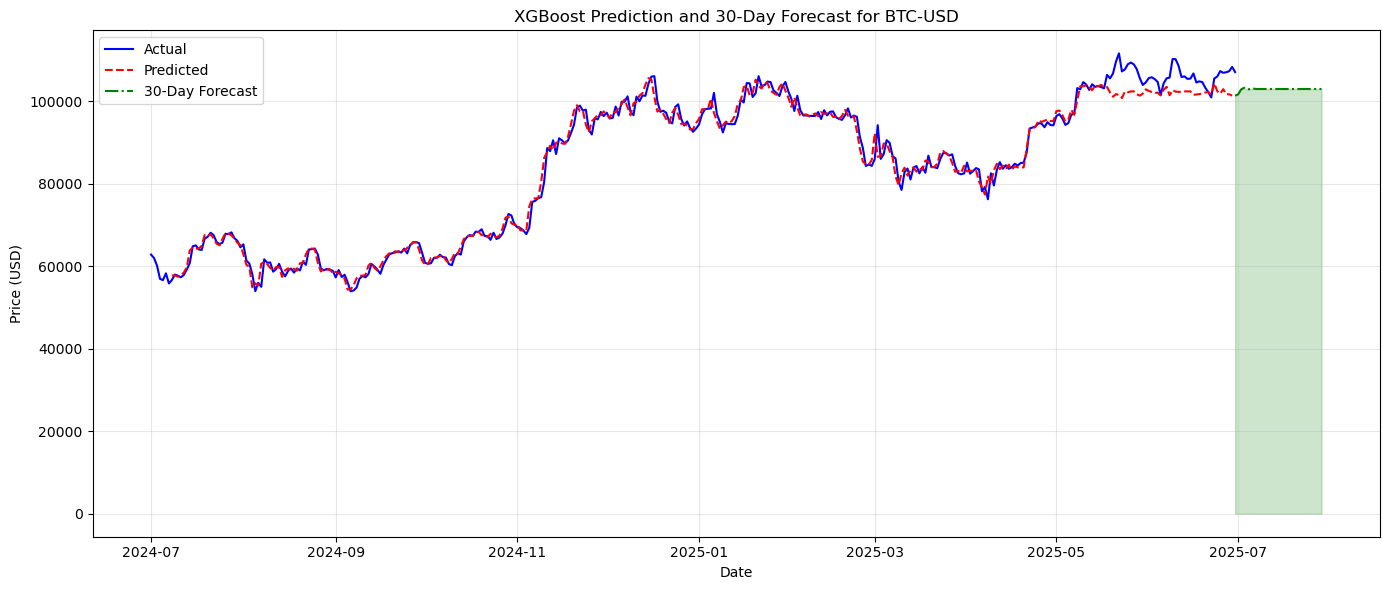


Processing ADA-USD
Metrics for ADA-USD: RMSE=0.0399, MAE=0.0318, MAPE=4.65%, R2=0.7068
Saved historical forecast CSV: ../../results/XGBoost_csv/separate_coins/ADA-USD_historical_forecast.csv
Saved test forecast CSV: ../../results/XGBoost_csv/separate_coins/ADA-USD_test_forecast.csv
Saved future forecast CSV: ../../results/XGBoost_csv/separate_coins/ADA-USD_future_forecast.csv
Saved model to: ../../saved_models/xgb_model_ADA-USD.pkl


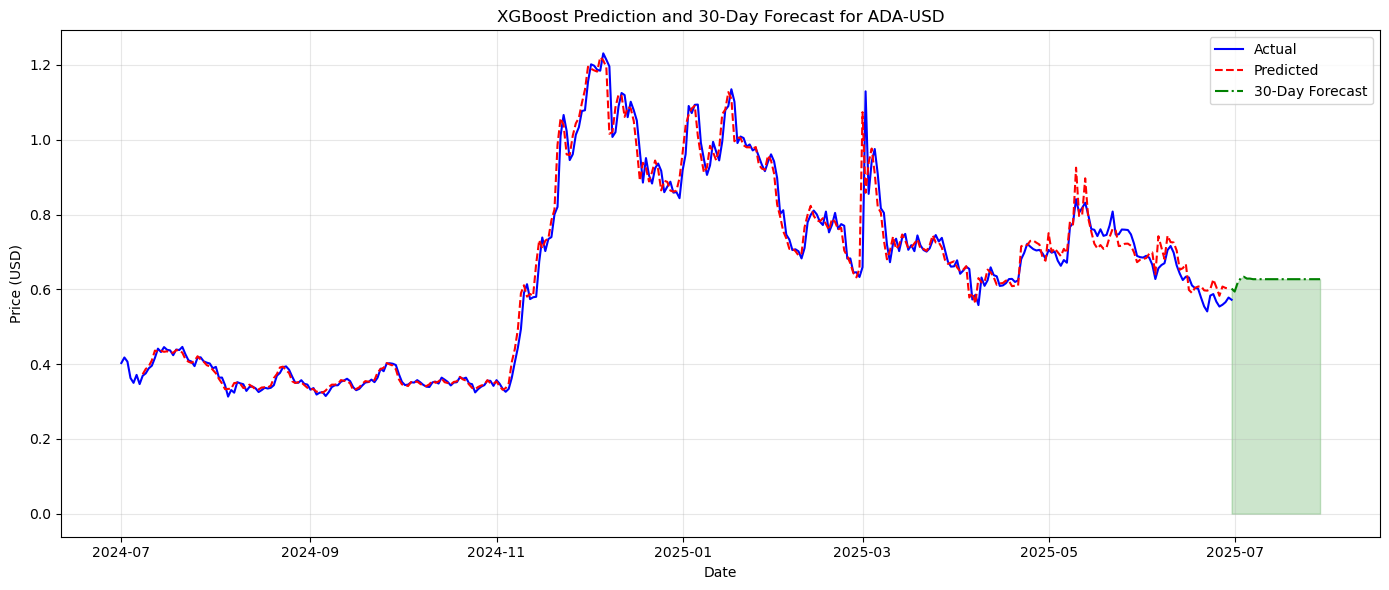


Processing BCH-USD
Metrics for BCH-USD: RMSE=21.2943, MAE=17.0008, MAPE=4.06%, R2=0.7510
Saved historical forecast CSV: ../../results/XGBoost_csv/separate_coins/BCH-USD_historical_forecast.csv
Saved test forecast CSV: ../../results/XGBoost_csv/separate_coins/BCH-USD_test_forecast.csv
Saved future forecast CSV: ../../results/XGBoost_csv/separate_coins/BCH-USD_future_forecast.csv
Saved model to: ../../saved_models/xgb_model_BCH-USD.pkl


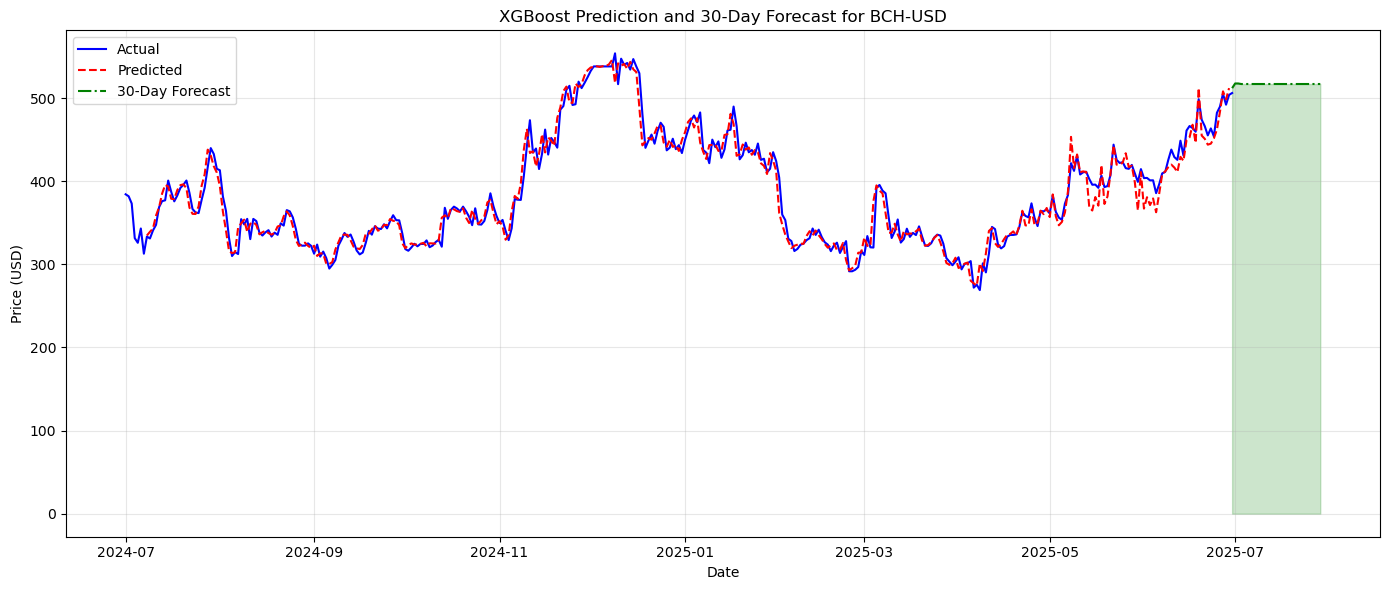

Saved combined metrics CSV at ../../results/XGBoost_csv/separate_coins/xgb_metrics_summary.csv


In [2]:
import os
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

df = pd.read_csv('../../data/cleaned/crypto_dataset_cleaned.csv', parse_dates=['Date'], index_col='Date')
rep_df = pd.read_csv('../../data/processed/representative_coins.csv')
rep_coins = rep_df['Representative_Coin'].tolist()

output_dir = '../../results/XGBoost_csv/separate_coins'
os.makedirs(output_dir, exist_ok=True)
os.makedirs('../../saved_models', exist_ok=True)

metrics_records = []

def create_features_for_xgboost(data: pd.DataFrame, coin: str, lags=5):
    df_coin = data[[coin]].copy()
    df_coin.rename(columns={coin: 'close'}, inplace=True)
    for lag in range(1, lags+1):
        df_coin[f'lag_{lag}'] = df_coin['close'].shift(lag)
    df_coin['ma_3'] = df_coin['close'].rolling(window=3).mean()
    df_coin['ma_7'] = df_coin['close'].rolling(window=7).mean()
    df_coin['returns'] = df_coin['close'].pct_change()
    df_coin['volatility_7'] = df_coin['returns'].rolling(window=7).std()
    df_coin['target'] = df_coin['close'].shift(-1)
    return df_coin.dropna()

def generate_signals(prices):
    signals = ['Hold']
    for i in range(1, len(prices)):
        if prices[i] > prices[i-1]:
            signals.append('Buy')
        elif prices[i] < prices[i-1]:
            signals.append('Sell')
        else:
            signals.append('Hold')
    return signals

for coin in rep_coins:
    print(f"\nProcessing {coin}")
    feat_df = create_features_for_xgboost(df, coin)
    train_size = int(len(feat_df) * 0.8)
    train = feat_df.iloc[:train_size]
    test = feat_df.iloc[train_size:]

    X_train = train.drop(columns=['target'])
    y_train = train['target']
    X_test = test.drop(columns=['target'])
    y_test = test['target']

    X_all = feat_df.drop(columns=['target'])
    y_actual_all = feat_df['close'].values
    idx_all = feat_df.index

    model = XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42)
    model.fit(X_train, y_train)

    # *** Predict for ALL data after feature warm-up ***
    y_pred_all = model.predict(X_all)
    signals_all = generate_signals(y_pred_all)

    # Metrics on test only
    y_pred_test = y_pred_all[train_size:]
    signals_test = generate_signals(y_pred_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    mae = mean_absolute_error(y_test, y_pred_test)
    mape = np.mean(np.abs((y_test - y_pred_test) / y_test.clip(lower=1e-10))) * 100
    r2 = r2_score(y_test, y_pred_test)

    print(f"Metrics for {coin}: RMSE={rmse:.4f}, MAE={mae:.4f}, MAPE={mape:.2f}%, R2={r2:.4f}")

    # Historical forecast DataFrame: all rows after warm-up
    hist_df = pd.DataFrame({
        'Date': idx_all,
        'Actual': y_actual_all,
        'Predicted': y_pred_all,
        'Signal': signals_all
    })
    hist_csv_path = os.path.join(output_dir, f"{coin}_historical_forecast.csv")
    hist_df.to_csv(hist_csv_path, index=False)

    # Test forecast DataFrame: test rows only
    test_df = pd.DataFrame({
        'Date': idx_all[train_size:],
        'Actual': y_test.values,
        'Predicted': y_pred_test,
        'Signal': signals_test
    })
    test_csv_path = os.path.join(output_dir, f"{coin}_test_forecast.csv")
    test_df.to_csv(test_csv_path, index=False)

    # 30-day future forecast recursively
    last_features = feat_df.iloc[-1].copy()
    future_preds = []
    future_dates = pd.date_range(start=feat_df.index[-1] + pd.Timedelta(days=1), periods=30)

    for _ in range(30):
        feat_vector = last_features.drop('target').values.reshape(1, -1)
        pred = model.predict(feat_vector)[0]
        future_preds.append(pred)
        # Update lags for next prediction
        for lag in range(5, 1, -1):
            last_features[f'lag_{lag}'] = last_features[f'lag_{lag-1}']
        last_features['lag_1'] = pred
        last_features['close'] = pred

    future_preds = np.array(future_preds)
    future_signals = generate_signals(future_preds)

    future_df = pd.DataFrame({
        'Date': future_dates,
        'Actual': [np.nan] * 30,
        'Predicted': future_preds,
        'Signal': future_signals
    })
    future_csv_path = os.path.join(output_dir, f"{coin}_future_forecast.csv")
    future_df.to_csv(future_csv_path, index=False)

    print(f"Saved historical forecast CSV: {hist_csv_path}")
    print(f"Saved test forecast CSV: {test_csv_path}")
    print(f"Saved future forecast CSV: {future_csv_path}")

    # Save model
    model_path = os.path.join('../../saved_models', f'xgb_model_{coin}.pkl')
    with open(model_path, 'wb') as f:
        pickle.dump(model, f)
    print(f"Saved model to: {model_path}")

    metrics_records.append({
        'Coin': coin,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape,
        'R2': r2
    })

    # Plot: actual from beginning, predicted for all, future forecast
    plt.figure(figsize=(14, 6))
    plt.plot(df.index, df[coin], label='Actual', color='blue')
    plt.plot(idx_all, y_pred_all, label='Predicted', color='red', linestyle='--')
    plt.plot(future_dates, future_preds, label='30-Day Forecast', color='green', linestyle='-.')
    plt.fill_between(future_dates, future_preds, alpha=0.2, color='green')
    plt.title(f"XGBoost Prediction and 30-Day Forecast for {coin}")
    plt.xlabel('Date')
    plt.ylabel('Price (USD)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Save combined metrics csv for all coins
metrics_df = pd.DataFrame(metrics_records)
metrics_csv_path = os.path.join(output_dir, 'xgb_metrics_summary.csv')
metrics_df.to_csv(metrics_csv_path, index=False)
print(f"Saved combined metrics CSV at {metrics_csv_path}")
